In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
plt.style.use('ggplot')

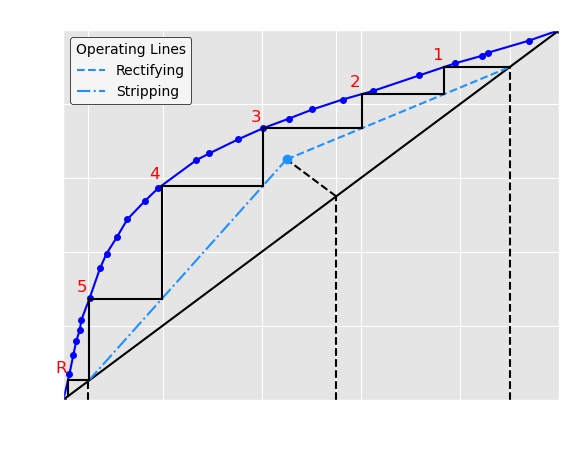

In [27]:
# load data
data = pd.read_csv('methanol_water_vle_data.csv')
x_methanol = data['x_methanol']
y_methanol = data['y_methanol']

fig, ax = plt.subplots()
ax.plot(x_methanol, y_methanol, 'o-', color='blue', markersize=4)
ax.plot([0, 1], [0, 1], 'k')  # y = x

# constants for operating lines
R, x_D = 1.25, 0.90  # reflux ratio and distillate composition
B, x_B = 2.0, 0.05  # boilup ratio and bottoms composition
z = 0.55  # feed composition

# plot distillate, bottoms, and feed compositions
points = [x_D, x_B, z]
labels = [r'$x_D$', r'$x_B$', r'$z$']
for point, label in zip(points, labels):
    ax.plot([point, point], [0, point], color='k', linestyle='--')

# operating line functions
def top_line(x): return R / (R + 1) * x + x_D / (R + 1)
def bottom_line(x): return (B + 1) / B * x - x_B / B

# finding intersection of operating lines
intersection_x = fsolve(lambda x: top_line(x) - bottom_line(x), 0.5)[0]
intersection_y = top_line(intersection_x)
ax.plot(intersection_x, intersection_y, 'o', color='dodgerblue', zorder=10)

def plot_line_and_markers(x_range, function, color, label, ls='-'):
    x_vals = np.linspace(*x_range, 100)
    ax.plot(x_vals, function(x_vals), color=color, label=label, ls=ls)

# plot operating lines
plot_line_and_markers((intersection_x, x_D), top_line, 'dodgerblue', 'Rectifying', '--')
plot_line_and_markers((x_B, intersection_x), bottom_line, 'dodgerblue', 'Stripping', '-.')

# q-line
ax.plot([z, intersection_x], [z, intersection_y], 'k--')

# McCabe-Thiele stage-stepping
stage_x, stage_y = [x_D], [x_D]  # starting at distillate composition
while stage_x[-1] > x_B:
    new_x = np.interp(stage_y[-1], y_methanol, x_methanol)  # move horizontally to equilibrium curve
    new_y = top_line(new_x) if new_x > intersection_x else bottom_line(new_x)  # move vertically to operating line

    if new_x < x_B:
        new_y = new_x

    stage_x.extend([new_x, new_x])
    stage_y.extend([stage_y[-1], new_y])

# plot stages
for i in range(0, len(stage_x) - 1):
    ax.plot([stage_x[i], stage_x[i+1]], [stage_y[i], stage_y[i]], 
            'k-', markersize=4)  # horizontal
    ax.plot([stage_x[i+1], stage_x[i+1]], [stage_y[i], stage_y[i+1]], 
            'k-', markersize=4)  # vertical
    if i % 2 == 0:
        if i != len(stage_x) - 2 and i != len(stage_x) - 3:
            ax.annotate(str(i//2 + 1), (stage_x[i+1], stage_y[i+1]), fontsize=12, 
                        textcoords="offset points", xytext=(-5,5), ha='center', color='red')
        else:
            ax.annotate('R', (stage_x[i+1], stage_y[i+1]), fontsize=12, 
                        textcoords="offset points", xytext=(-5,5), ha='center', color='red')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# adding some ticks and labels
current_ticks = list(ax.get_xticks())
current_labels = list(ax.get_xticklabels())
ax.set_xticks(current_ticks + points)
ax.set_xticklabels(current_labels + labels)


ax.set_xlabel(r'$x_\text{MeOH}$', color='white')
ax.set_ylabel(r'$y_\text{MeOH}$', color='white')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('McCabe-Thiele Diagram for Methanol-Water System', fontsize=12, color='white')
fig.patch.set_alpha(0.0)
ax.tick_params(colors='white', which='both')
ax.legend(title='Operating Lines', frameon=True, facecolor='whitesmoke', 
          edgecolor='black', framealpha=1)
# plt.savefig('../images/mccabe_thiele/final_mccabe_thiele_plot.png', dpi=500, bbox_inches='tight')
plt.show()


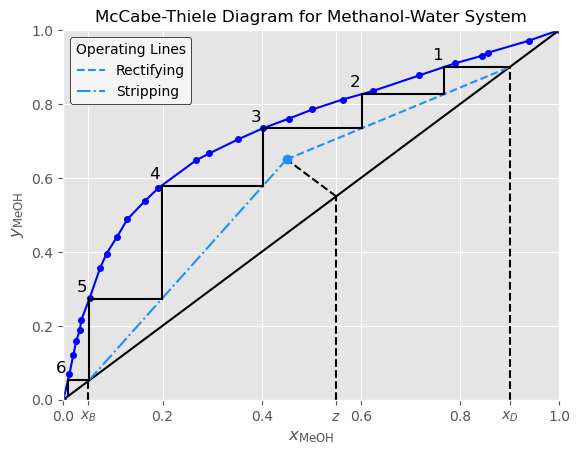

In [18]:
# load data
data = pd.read_csv('methanol_water_vle_data.csv')
x_methanol = data['x_methanol']
y_methanol = data['y_methanol']

fig, ax = plt.subplots()
ax.plot(x_methanol, y_methanol, 'o-', color='blue', markersize=4)
ax.plot([0, 1], [0, 1], 'k')  # y = x

# constants for operating lines
R, x_D = 1.25, 0.90  # reflux ratio and distillate composition
B, x_B = 2.0, 0.05  # boilup ratio and bottoms composition
z = 0.55  # feed composition

# plot distillate, bottoms, and feed compositions
points = [x_D, x_B, z]
labels = [r'$x_D$', r'$x_B$', r'$z$']
for point, label in zip(points, labels):
    ax.plot([point, point], [0, point], color='k', linestyle='--')

# operating line functions
def top_line(x): return R / (R + 1) * x + x_D / (R + 1)
def bottom_line(x): return (B + 1) / B * x - x_B / B

# finding intersection of operating lines
intersection_x = fsolve(lambda x: top_line(x) - bottom_line(x), 0.5)[0]
intersection_y = top_line(intersection_x)
ax.plot(intersection_x, intersection_y, 'o', color='dodgerblue', zorder=10)

def plot_line_and_markers(x_range, function, color, label, ls='-'):
    x_vals = np.linspace(*x_range, 100)
    ax.plot(x_vals, function(x_vals), color=color, label=label, ls=ls)

# plot operating lines
plot_line_and_markers((intersection_x, x_D), top_line, 'dodgerblue', 'Rectifying', '--')
plot_line_and_markers((x_B, intersection_x), bottom_line, 'dodgerblue', 'Stripping', '-.')

# q-line
ax.plot([z, intersection_x], [z, intersection_y], 'k--')

# McCabe-Thiele stage-stepping
stage_x, stage_y = [x_D], [x_D]  # starting at distillate composition
while stage_x[-1] > x_B:
    new_x = np.interp(stage_y[-1], y_methanol, x_methanol)  # move horizontally to equilibrium curve
    new_y = top_line(new_x) if new_x > intersection_x else bottom_line(new_x)  # move vertically to operating line

    if new_x < x_B:
        new_y = new_x

    stage_x.extend([new_x, new_x])
    stage_y.extend([stage_y[-1], new_y])

# plot stages
for i in range(0, len(stage_x) - 1):
    ax.plot([stage_x[i], stage_x[i+1]], [stage_y[i], stage_y[i]], 
            'k-', markersize=4)  # horizontal
    ax.plot([stage_x[i+1], stage_x[i+1]], [stage_y[i], stage_y[i+1]], 
            'k-', markersize=4)  # vertical
    if i % 2 == 0:
        ax.annotate(str(i//2 + 1), (stage_x[i+1], stage_y[i+1]), fontsize=12, 
                    textcoords="offset points", xytext=(-5,5), ha='center')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# adding some ticks and labels
current_ticks = list(ax.get_xticks())
current_labels = list(ax.get_xticklabels())
ax.set_xticks(current_ticks + points)
ax.set_xticklabels(current_labels + labels)

ax.legend(title='Operating Lines', frameon=True, facecolor='whitesmoke', 
          edgecolor='black', framealpha=1)
ax.set_xlabel(r'$x_\text{MeOH}$')
ax.set_ylabel(r'$y_\text{MeOH}$')
ax.set_title('McCabe-Thiele Diagram for Methanol-Water System', fontsize=12)
fig.patch.set_alpha(0.0)
# plt.savefig('../solutions/figs/mccabe.png', dpi=500, bbox_inches='tight')
plt.show()